In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/saichaitanyareddyai/best-selling-books-dataset/best sellin books total.csv


In [2]:
book_url= "/kaggle/input/datasets/saichaitanyareddyai/best-selling-books-dataset/best sellin books total.csv"


In [3]:
import pandas as pd
df = pd.read_csv(book_url, encoding='cp1252')

In [4]:
df.head()

,Book name,Author,Rating,reviews count,form,price,Reading age,Print Length,Publishing date,Genre,id_2023,id_2024,id_2025
0,Atomic Habits: An Easy & Proven Way to Build G...,James Clear,4.8 out of 5 stars,145747,Hardcover,$18.88,NaN,320.0,16/10/2018,Self-Improvement,#1,#3,#6
1,"Iron Flame (Standard Edition) (The Empyrean, 2)",Rebecca Yarros,4.7 out of 5 stars,395512,Hardcover,$11.05,NaN,640.0,07/11/2023,Fiction & Action & Adventure,#2,#13,NaN
2,Spare,Prince Harry The Duke of Sussex,4.5 out of 5 stars,116101,Hardcover,$11.99,NaN,416.0,"January 10, 2023",Biographies & Memoirs,#3,NaN,NaN
3,Fourth Wing,Rebecca Yarros,4.8 out of 5 stars,472618,Paperback,$13.62,NaN,544.0,17/09/2024,Fiction & Action & Adventure,#4,#16,#76
4,The Woman in Me,Britney Spears,4.4 out of 5 stars,51520,Hardcover,$11.37,NaN,288.0,"October 24, 2023",Biographies & Memoirs,#5,NaN,NaN


In [5]:
df.dtypes

Book name           object
Author              object
Rating              object
reviews count        int64
form                object
price               object
Reading age         object
Print Length       float64
Publishing date     object
Genre               object
id_2023             object
id_2024             object
id_2025             object
dtype: object

Data cleanup: Converting the Publishing date to Datetime type.

In [6]:
df["Publishing date"] = pd.to_datetime(df["Publishing date"],
    format="mixed",
    errors="coerce")

In [7]:
df["year"] = df["Publishing date"].dt.year

In [8]:
df.dtypes

Book name                  object
Author                     object
Rating                     object
reviews count               int64
form                       object
price                      object
Reading age                object
Print Length              float64
Publishing date    datetime64[ns]
Genre                      object
id_2023                    object
id_2024                    object
id_2025                    object
year                        int32
dtype: object

Get the ratings as numbers

In [15]:
df["Final_Ratings"] = df["Rating"].str[:4].str.extract(r"(\d+\.\d+|\d+)")[0].astype("float")
print(df)

                                             Book name  \
0    Atomic Habits: An Easy & Proven Way to Build G...   
1      Iron Flame (Standard Edition) (The Empyrean, 2)   
2                                                Spare   
3                                          Fourth Wing   
4                                      The Woman in Me   
..                                                 ...   
205            A People's History of the United States   
206                                          Bob Books   
207                                         Alchemised   
208       The Next Conversation: Argue Less, Talk More   
209                     A Beautiful Year in the Bible:   

                                        Author              Rating  \
0                                  James Clear  4.8 out of 5 stars   
1                               Rebecca Yarros  4.7 out of 5 stars   
2             Prince Harry  The Duke of Sussex  4.5 out of 5 stars   
3                      

In [16]:
df.head(5)

,Book name,Author,Rating,reviews count,form,price,Reading age,Print Length,Publishing date,Genre,id_2023,id_2024,id_2025,year,Final_Ratings
0,Atomic Habits: An Easy & Proven Way to Build G...,James Clear,4.8 out of 5 stars,145747,Hardcover,$18.88,NaN,320.0,2018-10-16,Self-Improvement,#1,#3,#6,2018,4.8
1,"Iron Flame (Standard Edition) (The Empyrean, 2)",Rebecca Yarros,4.7 out of 5 stars,395512,Hardcover,$11.05,NaN,640.0,2023-07-11,Fiction & Action & Adventure,#2,#13,NaN,2023,4.7
2,Spare,Prince Harry The Duke of Sussex,4.5 out of 5 stars,116101,Hardcover,$11.99,NaN,416.0,2023-01-10,Biographies & Memoirs,#3,NaN,NaN,2023,4.5
3,Fourth Wing,Rebecca Yarros,4.8 out of 5 stars,472618,Paperback,$13.62,NaN,544.0,2024-09-17,Fiction & Action & Adventure,#4,#16,#76,2024,4.8
4,The Woman in Me,Britney Spears,4.4 out of 5 stars,51520,Hardcover,$11.37,NaN,288.0,2023-10-24,Biographies & Memoirs,#5,NaN,NaN,2023,4.4


Find the columns containing null values.

In [17]:
df.isna().sum()

Book name            0
Author               0
Rating               0
reviews count        0
form                 0
price                0
Reading age        139
Print Length         2
Publishing date      0
Genre                0
id_2023            110
id_2024            100
id_2025            112
year                 0
Final_Ratings        0
dtype: int64

In [13]:
r1 = (df.groupby('Genre')['reviews count'].sum().sort_values(ascending=False).head(5))
r1

Genre
Fiction & Action & Adventure     10205195
Mystery & Thriller & Suspense     3825243
Reading & Writing                 1371034
Self-Improvement                   928798
Politics & Social Sciences         577978
Name: reviews count, dtype: int64

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.barplot(
    x=r1.values,
    y=r1.index,
    palette="viridis"
)

plt.title("Top 5 Categories by Total Sales")
plt.xlabel("Genre")
plt.ylabel("Ratings")

plt.show()


NameError: name 'r1' is not defined

<Figure size 800x500 with 0 Axes>

/tmp/ipykernel_193/2513014875.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5, x='reviews count', y='Genre', palette='Blues_r')


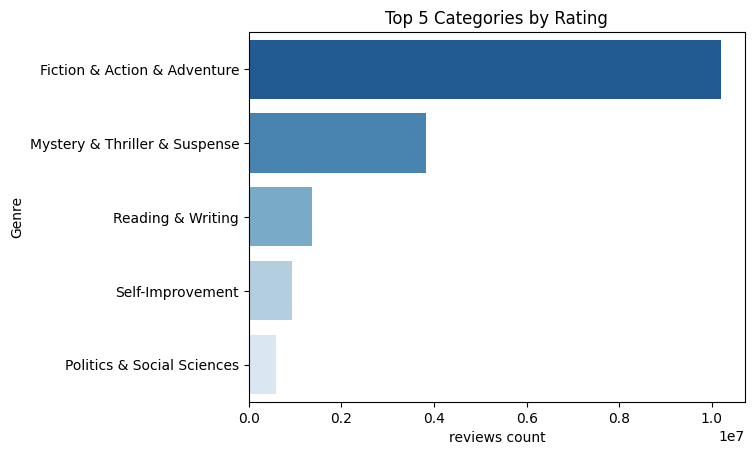

In [15]:
top5 = (
    df.groupby('Genre', as_index=False)['reviews count']
      .sum()
      .sort_values(by='reviews count', ascending=False)
      .head(5)
)

sns.barplot(data=top5, x='reviews count', y='Genre', palette='Blues_r')

plt.title("Top 5 Categories by Rating")
plt.show()

/tmp/ipykernel_193/683876231.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5,


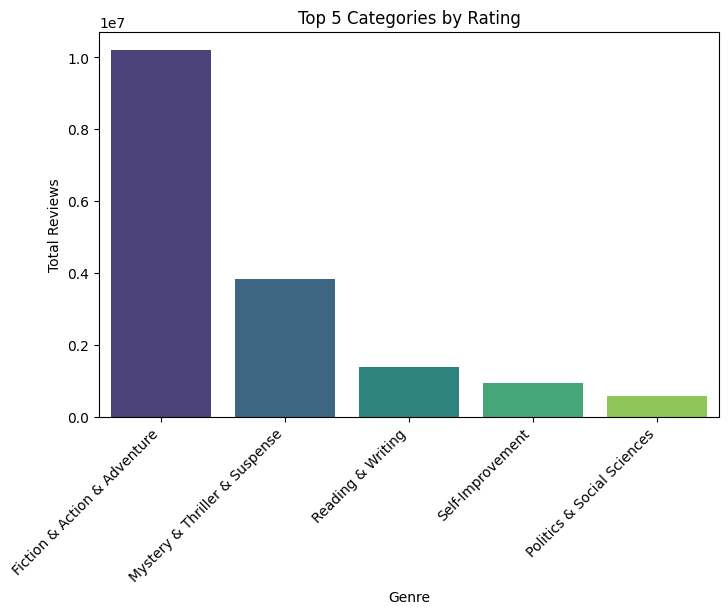

In [18]:
plt.figure(figsize=(8, 5))

sns.barplot(data=top5,
    x='Genre',
    y='reviews count',
    palette="viridis"
)

plt.title("Top 5 Categories by Rating")
plt.xlabel("Genre")
plt.ylabel("Total Reviews")

plt.xticks(rotation=45, ha='right')
plt.show()

Getting the top 5 authors

In [20]:
top5auth = (
    df.groupby('Author', as_index=False)['reviews count']
      .sum()
      .sort_values(by='reviews count', ascending=False)
      .head(5)
)
#(df.groupby('Author' as_index=False)['reviews count'].sum().sort_values(ascending=False).head(5))
top5auth

,Author,reviews count
59,Freida McFadden,2808693
134,Sarah J. Maas,2260824
39,Colleen Hoover,1995627
125,Rebecca Yarros,1156263
92,Kristin Hannah,909363


/tmp/ipykernel_193/4098337179.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5auth,


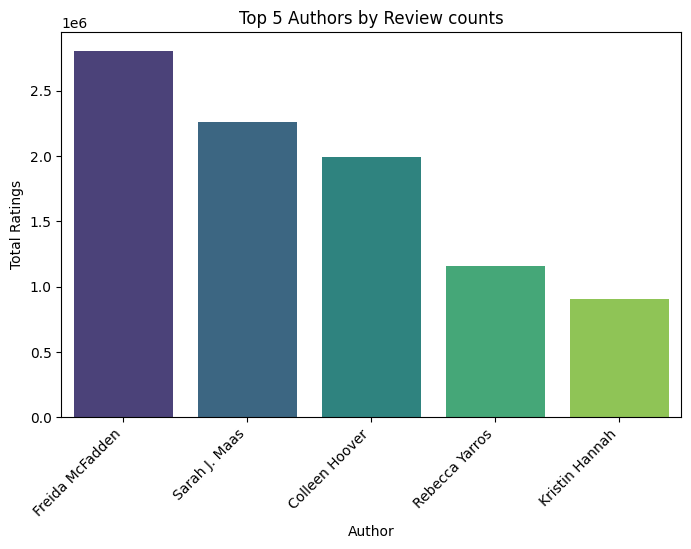

In [21]:
plt.figure(figsize=(8, 5))

sns.barplot(data=top5auth,
    x='Author',
    y='reviews count',
    palette="viridis"
)

plt.title("Top 5 Authors by Review counts")
plt.xlabel("Author")
plt.ylabel("Total Ratings")

plt.xticks(rotation=45, ha='right')
plt.show()

In [22]:
top3form = df.groupby('form').size().sort_values(ascending=False).head(3)
top3form

form
Paperback     106
Hardcover      84
Board book     17
dtype: int64

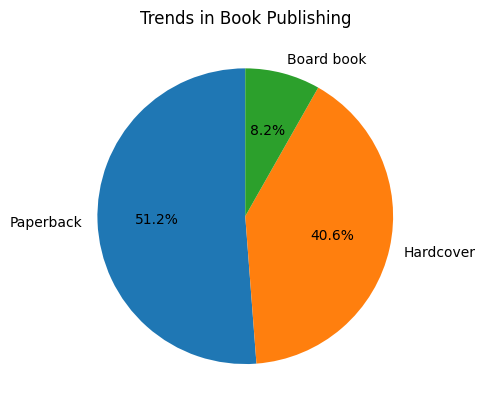

In [23]:
plt.pie(
    top3form.values,
    labels=top3form.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Trends in Book Publishing")
plt.show()

In [29]:
topyear = df.groupby('year').size().reset_index(name='Count')
topyear

,year,Count
0,1959,1
1,1961,1
2,1982,1
3,1990,2
4,1991,1
5,1994,2
6,1995,1
7,1996,1
8,1997,1
9,1998,2


In [30]:
last_10_years = topyear.tail(10)
last_10_years

,year,Count
22,2016,11
23,2017,3
24,2018,12
25,2019,14
26,2020,15
27,2021,9
28,2022,19
29,2023,32
30,2024,35
31,2025,19


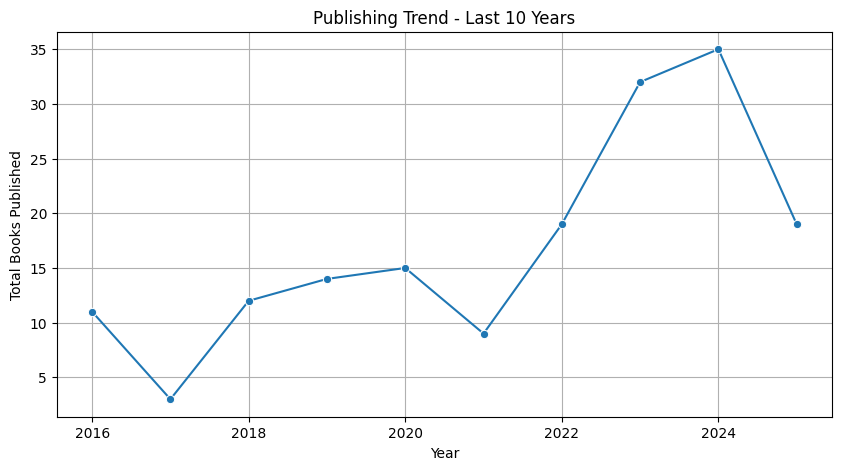

In [31]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=last_10_years,
    x='year',
    y='Count',
    marker='o'
)

plt.title('Publishing Trend - Last 10 Years')
plt.xlabel('Year')
plt.ylabel('Total Books Published')
plt.grid(True)

plt.show()

In [18]:
top5authrating = (
    df.groupby('Author', as_index=False)['Final_Ratings']
      .sum()
      .sort_values(by='Final_Ratings', ascending=False)
      .head(5)
)
top5authrating

,Author,Final_Ratings
134,Sarah J. Maas,46.2
59,Freida McFadden,35.0
39,Colleen Hoover,27.8
38,Coco Wyo,24.0
43,Dav Pilkey,19.1


/tmp/ipykernel_58/2739772590.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5authrating,


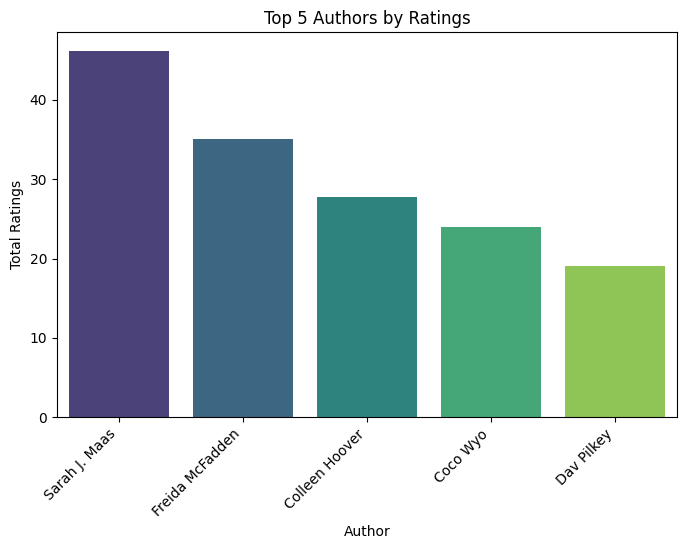

In [21]:
plt.figure(figsize=(8, 5))

sns.barplot(data=top5authrating,
    x='Author',
    y='Final_Ratings',
    palette="viridis"
)

plt.title("Top 5 Authors by Ratings")
plt.xlabel("Author")
plt.ylabel("Total Ratings")

plt.xticks(rotation=45, ha='right')
plt.show()